<a href="https://colab.research.google.com/github/sivabharathi-k/sivabharathi-codebooster-2026/blob/main/Day3/Miniproject3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [17]:
import requests
import pandas as pd

# API details
API_KEY = 'f93e5d4a1dc43dd0f13a34d059136b16'

BASE_URL = 'https://api.openweathermap.org/data/2.5/weather'

CITIES = [
    'Coimbatore',
    'New York',
    'Tokyo',
    'Paris',
    'Dubai',
    'Singapore',
    'Sydney',
    'Toronto'
]


# Function to fetch weather data
def fetch_weather(city, API_KEY):

    """
    Fetch current weather data for a given city.
    Returns weather details dictionary or None on failure.
    """

    params = {
        'q': city,
        'appid': API_KEY,
        'units': 'metric'
    }

    try:

        response = requests.get(
            BASE_URL,
            params=params,
            timeout=10
        )

        if response.status_code == 200:

            data = response.json()

            return {
                'city': data['name'],
                'temperature': data['main']['temp'],
                'description': data['weather'][0]['description'],
                'icon': data['weather'][0]['icon'],
                'humidity': data['main']['humidity'],
                'wind_speed': data['wind']['speed'],
                'pressure': data['main']['pressure'],
                'visibility': data.get('visibility', 0),
                'sunrise': data['sys']['sunrise'],
                'sunset': data['sys']['sunset']
            }

        else:

            print(f"Error fetching weather data for {city}")
            print(f"Status code: {response.status_code}")

            return None

    except requests.exceptions.RequestException as e:

        print(f"Request failed: {e}")

        return None


# Call API for all cities
print("Calling Weather API...\n")

weather_records = []

for city in CITIES:

    print(f"Fetching weather for {city}...", end=' ')

    record = fetch_weather(city, API_KEY)

    if record:

        weather_records.append(record)

        print(
            f"{record['temperature']}°C, "
            f"{record['description']}"
        )

    else:

        print("Failed")


# Final Output
print("\nWeather Records:\n")

for record in weather_records:
    print(record)

Calling Weather API...

Fetching weather for Coimbatore... 33.88°C, scattered clouds
Fetching weather for New York... 19.67°C, clear sky
Fetching weather for Tokyo... 24.95°C, broken clouds
Fetching weather for Paris... 29.34°C, clear sky
Fetching weather for Dubai... 37.96°C, clear sky
Fetching weather for Singapore... 31.75°C, broken clouds
Fetching weather for Sydney... 19.14°C, light rain
Fetching weather for Toronto... 18.25°C, broken clouds

Weather Records:

{'city': 'Coimbatore', 'temperature': 33.88, 'description': 'scattered clouds', 'icon': '03d', 'humidity': 52, 'wind_speed': 4.12, 'pressure': 1008, 'visibility': 7000, 'sunrise': 1779841706, 'sunset': 1779887424}
{'city': 'New York', 'temperature': 19.67, 'description': 'clear sky', 'icon': '01d', 'humidity': 78, 'wind_speed': 3.6, 'pressure': 1013, 'visibility': 10000, 'sunrise': 1779874191, 'sunset': 1779927412}
{'city': 'Tokyo', 'temperature': 24.95, 'description': 'broken clouds', 'icon': '04n', 'humidity': 75, 'wind_sp

In [22]:
import pandas as pd
weather_df=pd.DataFrame(weather_records)
print('Weather DataFrame created:')
print(weather_df.to_string(index=False))
print(weather_df.shape)
print(f'Missing Values:',{weather_df.isnull().sum().sum()})
print(f'\nData types:')
print(weather_df.dtypes)

Weather DataFrame created:
      city  temperature      description icon  humidity  wind_speed  pressure  visibility    sunrise     sunset
Coimbatore        33.88 scattered clouds  03d        52        4.12      1008        7000 1779841706 1779887424
  New York        19.67        clear sky  01d        78        3.60      1013       10000 1779874191 1779927412
     Tokyo        24.95    broken clouds  04n        75        5.66      1008       10000 1779823749 1779875271
     Paris        29.34        clear sky  01d        39        4.12      1023       10000 1779854155 1779910794
     Dubai        37.96        clear sky  01d        34        5.66      1006       10000 1779845385 1779894144
 Singapore        31.75    broken clouds  04d        69        5.66      1009       10000 1779836178 1779880047
    Sydney        19.14       light rain  10n        79        4.12      1017       10000 1779828504 1779864988
   Toronto        18.25    broken clouds  04d        52        4.12      1012

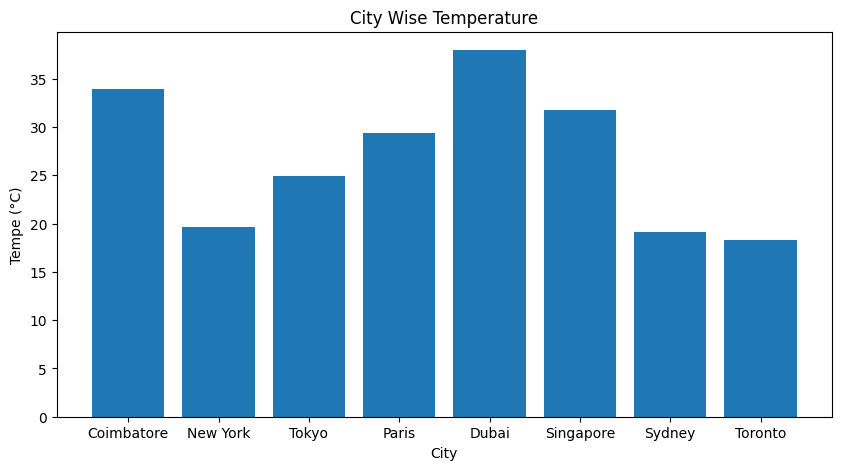

In [29]:
import matplotlib.pyplot as plt


plt.figure(figsize=(10,5))

plt.bar(
    weather_df['city'],
    weather_df['temperature']
)

plt.title('City Wise Temperature')

plt.xlabel('City')

plt.ylabel('Tempe (°C)')

plt.show()